## part1: clone repo and create Quantum circuit base on paper

In [121]:
# سلول ۱: کلون کردن ریپازیتوری
!git clone https://github.com/hypahub/hypacadd_notebook.git

Cloning into 'hypacadd_notebook'...


In [123]:
# سلول ۲: رفتن به دایرکتوری پروژه
%cd hypacadd_notebook

C:\Users\Asus\hypacadd_notebook\mQNN\hypacadd_notebook\mQNN\hypacadd_notebook


In [67]:
# سلول ۳: نصب کتابخانه‌های مورد نیاز
!pip install qiskit==0.45.0
!pip install qiskit-machine-learning==0.6.1
!pip install pennylane==0.33.0
!pip install torch numpy pandas scikit-learn matplotlib

In [ ]:
# سلول ۴: بررسی نصب صحیح
import qiskit
import pennylane as qml
print(f"Qiskit version: {qiskit.__version__}")
print(f"PennyLane version: {qml.__version__}")

In [71]:
# سلول ۵: نمایش ساختار درختی
!pip install directory-tree
from directory_tree import display_tree
display_tree('.')

/
├── cQNN_qisQNN/
│   ├── cQNN_HypaCADD.py
│   ├── cQNN_spec-file.txt
│   ├── defs_HypaCADD.py
│   ├── genodock_preprocessed/
│   │   ├── data_descriptions.txt
│   │   ├── genodock_1_norm.txt
│   │   ├── genodock_2_norm.txt
│   │   ├── genodock_3_norm.txt
│   │   ├── genodock_4_norm.txt
│   │   ├── genodock_hypahub_viral_fix_norm.txt
│   │   ├── genodock_nonhuman_norm.txt
│   │   ├── genodock_platinum_1_af_norm.txt
│   │   ├── genodock_platinum_4_af_norm.txt
│   │   ├── genodock_platinum_gdk2_af_norm.txt
│   │   └── genodock_platinum_gdk3_af_norm.txt
│   ├── qisQNN_HypaCADD.py
│   ├── qisQNN_spec-file.txt
│   └── README.txt
├── LICENSE.md
├── mQNN/
│   ├── data/
│   │   ├── genodock_cluster3_fix_train.tsv
│   │   └── genodock_cluster3_fix_val.tsv
│   ├── output/
│   │   ├── trained_model.p
│   │   ├── trained_model.pdf
│   │   ├── trained_model_fix.pdf
│   │   ├── trained_model_prediction.tsv
│   │   └── trained_model_scaler.p
│   └── weighted_mQNN.ipynb
└── README.md


C:\Users\Asus\AppData\Local\Temp\ipykernel_35240\1865060605.py:4: DeprecationWarning: The `display_tree` Function is Deprecated and will be Removed in a Future Release. Please use `DirectoryTree` Instead. End of Life Date is "31st December 2024".
  display_tree('.')


In [73]:
# سلول ۶: Import کتابخانه‌ها
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# Qiskit imports
from qiskit import QuantumCircuit, Aer
from qiskit.circuit import Parameter
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN

In [75]:
# سلول ۷: تعریف معماری QNN (مطابق مقاله - Figure 2)
def create_qnn_circuit(num_features, num_layers=3):
    """
    ساخت مدار QNN با معماری Farhi-Neven
    - گیت‌های RZX و RXX
    - یک qubit خروجی (readout)
    """
    num_qubits = num_features + 1  # +1 برای readout qubit
    qc = QuantumCircuit(num_qubits)
    
    # پارامترهای ورودی (feature map)
    input_params = [Parameter(f'x_{i}') for i in range(num_features)]
    
    # پارامترهای قابل آموزش
    weight_params = [Parameter(f'θ_{i}') for i in range(num_features * num_layers)]
    
    # Feature Map: RX gates روی input qubits
    for i in range(num_features):
        qc.rx(input_params[i] * np.pi, i)
    
    # Initialize readout qubit to |1⟩
    qc.x(num_qubits - 1)
    
    # Variational layers
    param_idx = 0
    for layer in range(num_layers):
        for i in range(num_features):
            if layer % 2 == 0:
                # RZX layer
                qc.rzx(weight_params[param_idx], i, num_qubits - 1)
            else:
                # RXX layer
                qc.rxx(weight_params[param_idx], i, num_qubits - 1)
            param_idx += 1
    
    return qc, input_params, weight_params

# ساخت مدار برای 4 ویژگی
qc, inp, weights = create_qnn_circuit(num_features=4, num_layers=3)
print(qc.draw())

     ┌───────────┐┌───────────┐                                       »
q_0: ┤ Rx(π*x_0) ├┤0          ├───────────────────────────────────────»
     ├───────────┤│           │┌───────────┐                          »
q_1: ┤ Rx(π*x_1) ├┤           ├┤0          ├──────────────────────────»
     ├───────────┤│           ││           │┌───────────┐             »
q_2: ┤ Rx(π*x_2) ├┤  Rzx(θ_0) ├┤           ├┤0          ├─────────────»
     ├───────────┤│           ││  Rzx(θ_1) ││           │┌───────────┐»
q_3: ┤ Rx(π*x_3) ├┤           ├┤           ├┤  Rzx(θ_2) ├┤0          ├»
     └───┬───┬───┘│           ││           ││           ││  Rzx(θ_3) │»
q_4: ────┤ X ├────┤1          ├┤1          ├┤1          ├┤1          ├»
         └───┘    └───────────┘└───────────┘└───────────┘└───────────┘»
«     ┌───────────┐                                       ┌───────────┐»
«q_0: ┤0          ├───────────────────────────────────────┤0          ├»
«     │           │┌───────────┐                          │   

In [77]:
# سلول ۸ : بارگذاری داده‌های واقعی
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# بارگذاری داده آموزش از پوشه mQNN
train_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_train.tsv', sep='\t')
val_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_val.tsv', sep='\t')

print("ستون‌های موجود:")
print(train_data.columns.tolist())
print(f"\nتعداد نمونه آموزش: {len(train_data)}")
print(f"تعداد نمونه اعتبارسنجی: {len(val_data)}")

# نمایش چند نمونه
train_data.head()

ستون‌های موجود:
['volume_change_index', 'polarity_change_index', 'distance', 'molecular_weight', 'H_bond_donor', 'H_bond_acceptor', 'rotatable_bond', 'Polar_Surface_Area', 'bind_site', 'hydropathy_change_index', 'cluster', 'target']

تعداد نمونه آموزش: 5142
تعداد نمونه اعتبارسنجی: 5139


,volume_change_index,polarity_change_index,distance,molecular_weight,H_bond_donor,H_bond_acceptor,rotatable_bond,Polar_Surface_Area,bind_site,hydropathy_change_index,cluster,target
0,0.308631,2.0,14.833258,508.638,5,8,9,189.0,0,-0.4,0,0
1,-0.341037,-0.5,26.685061,255.310,2,6,3,122.0,0,1.9,0,0
2,-1.073462,-0.5,22.116748,393.443,1,7,11,74.7,0,3.1,0,0
3,-0.049753,0.0,13.589632,398.482,3,4,7,77.2,0,-0.3,0,0
4,0.341037,0.5,8.990741,650.977,3,5,5,92.8,0,-1.9,0,0


In [79]:
# سلول ۹: آماده‌سازی ویژگی‌ها (۴ ویژگی برای ۵ کیوبیت)

# ۴ ویژگی غیر ligand-specific (مطابق مقاله)
feature_cols = ['bind_site', 'distance', 'polarity_change_index', 'volume_change_index']

# بررسی وجود ستون‌ها
print("ویژگی‌های مورد نیاز:")
for col in feature_cols:
    exists = col in train_data.columns
    print(f"  {col}: {'✅' if exists else '❌'}")

# اگر ستون‌ها با نام دیگه‌ای هستن، اینجا تنظیم کن
# مثلاً شاید 'label' یا 'target' باشه به جای 'y'

# استخراج X و y
if 'label' in train_data.columns:
    label_col = 'label'
elif 'target' in train_data.columns:
    label_col = 'target'
else:
    label_col = train_data.columns[-1]  # آخرین ستون

print(f"\nستون برچسب: {label_col}")

# آماده‌سازی داده
X_train = train_data[feature_cols].values
y_train = train_data[label_col].values
X_val = val_data[feature_cols].values
y_val = val_data[label_col].values

# نرمال‌سازی
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"\nشکل داده آموزش: {X_train_scaled.shape}")
print(f"شکل داده اعتبارسنجی: {X_val_scaled.shape}")
print(f"توزیع برچسب‌ها (آموزش): 0={sum(y_train==0)}, 1={sum(y_train==1)}")

ویژگی‌های مورد نیاز:
  bind_site: ✅
  distance: ✅
  polarity_change_index: ✅
  volume_change_index: ✅

ستون برچسب: target

شکل داده آموزش: (5142, 4)
شکل داده اعتبارسنجی: (5139, 4)
توزیع برچسب‌ها (آموزش): 0=4806, 1=336


In [81]:
# سلول ۱۰: آموزش QNN با داده واقعی (اصلاح شده)

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# بارگذاری داده
train_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_train.tsv', sep='\t')
val_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_val.tsv', sep='\t')

# ۴ ویژگی غیر ligand-specific (مطابق مقاله برای IBM 5-qubit)
feature_cols = ['bind_site', 'distance', 'polarity_change_index', 'volume_change_index']
label_col = 'target'

# آماده‌سازی داده
X_train = train_data[feature_cols].values
y_train = train_data[label_col].values
X_val = val_data[feature_cols].values
y_val = val_data[label_col].values

# نرمال‌سازی به بازه [0, 1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("="*50)
print("📊 آمار داده‌ها:")
print("="*50)
print(f"تعداد نمونه آموزش: {len(X_train)}")
print(f"تعداد نمونه اعتبارسنجی: {len(X_val)}")
print(f"\nتوزیع برچسب‌ها (آموزش):")
print(f"  - Non-disruptive (0): {sum(y_train==0)}")
print(f"  - Disruptive (1): {sum(y_train==1)}")
print(f"\nنسبت عدم تعادل: {sum(y_train==0)/sum(y_train==1):.2f}:1")

📊 آمار داده‌ها:
تعداد نمونه آموزش: 5142
تعداد نمونه اعتبارسنجی: 5139

توزیع برچسب‌ها (آموزش):
  - Non-disruptive (0): 4806
  - Disruptive (1): 336

نسبت عدم تعادل: 14.30:1


In [95]:
# سلول ۱0: تعریف معماری QNN (مطابق Figure 2 مقاله)

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np

def create_qnn_circuit(num_features=4, num_layers=3):
    """
    ساخت مدار QNN با معماری Farhi-Neven
    مطابق مقاله HypaCADD (Figure 2)
    """
    num_qubits = num_features + 1  # +1 برای readout qubit
    qc = QuantumCircuit(num_qubits)
    
    # پارامترهای ورودی
    input_params = [Parameter(f'x_{i}') for i in range(num_features)]
    
    # پارامترهای قابل آموزش
    weight_params = [Parameter(f'θ_{i}') for i in range(num_features * num_layers)]
    
    # Feature Map: RX gates روی input qubits
    for i in range(num_features):
        qc.rx(input_params[i] * np.pi, i)
    
    # Initialize readout qubit to |1⟩
    qc.x(num_qubits - 1)
    
    # Variational layers (RZX-RXX-RZX مطابق مقاله)
    param_idx = 0
    for layer in range(num_layers):
        for i in range(num_features):
            if layer % 2 == 0:
                # RZX layer (لایه‌های 0 و 2)
                qc.rzx(weight_params[param_idx], i, num_qubits - 1)
            else:
                # RXX layer (لایه 1)
                qc.rxx(weight_params[param_idx], i, num_qubits - 1)
            param_idx += 1
    
    return qc, input_params, weight_params

# ساخت مدار
qc, input_params, weight_params = create_qnn_circuit(num_features=4, num_layers=3)

print("🔮 معماری QNN:")
print(f"   - تعداد کیوبیت: 5 (4 ورودی + 1 خروجی)")
print(f"   - تعداد لایه: 3 (RZX → RXX → RZX)")
print(f"   - تعداد پارامتر قابل آموزش: {len(weight_params)}")
print("\n📐 مدار کوانتومی:")
print(qc.draw())

🔮 معماری QNN:
   - تعداد کیوبیت: 5 (4 ورودی + 1 خروجی)
   - تعداد لایه: 3 (RZX → RXX → RZX)
   - تعداد پارامتر قابل آموزش: 12

📐 مدار کوانتومی:
     ┌───────────┐┌───────────┐                                       »
q_0: ┤ Rx(π*x_0) ├┤0          ├───────────────────────────────────────»
     ├───────────┤│           │┌───────────┐                          »
q_1: ┤ Rx(π*x_1) ├┤           ├┤0          ├──────────────────────────»
     ├───────────┤│           ││           │┌───────────┐             »
q_2: ┤ Rx(π*x_2) ├┤  Rzx(θ_0) ├┤           ├┤0          ├─────────────»
     ├───────────┤│           ││  Rzx(θ_1) ││           │┌───────────┐»
q_3: ┤ Rx(π*x_3) ├┤           ├┤           ├┤  Rzx(θ_2) ├┤0          ├»
     └───┬───┬───┘│           ││           ││           ││  Rzx(θ_3) │»
q_4: ────┤ X ├────┤1          ├┤1          ├┤1          ├┤1          ├»
         └───┘    └───────────┘└───────────┘└───────────┘└───────────┘»
«     ┌───────────┐                                       ┌─────

# part 2: prepare dataset and train the model

## train for 20 iteration with callback(COBYLA optimizer)

📊 آمار داده‌های اصلی:
Train: 5142 نمونه (0: 4806, 1: 336)
Val: 5139 نمونه (0: 4805, 1: 334)

📊 داده‌های انتخاب شده برای آموزش:
Train: 5142 (0: 4806, 1: 336)
Val: 5139 (0: 4805, 1: 334)

📐 مدار QNN (مطابق Figure 2 مقاله):
     ┌───────────┐┌───────────┐                                       »
q_0: ┤ Rx(π*x_0) ├┤0          ├───────────────────────────────────────»
     ├───────────┤│           │┌───────────┐                          »
q_1: ┤ Rx(π*x_1) ├┤           ├┤0          ├──────────────────────────»
     ├───────────┤│           ││           │┌───────────┐             »
q_2: ┤ Rx(π*x_2) ├┤  Rzx(θ_0) ├┤           ├┤0          ├─────────────»
     ├───────────┤│           ││  Rzx(θ_1) ││           │┌───────────┐»
q_3: ┤ Rx(π*x_3) ├┤           ├┤           ├┤  Rzx(θ_2) ├┤0          ├»
     └───┬───┬───┘│           ││           ││           ││  Rzx(θ_3) │»
q_4: ────┤ X ├────┤1          ├┤1          ├┤1          ├┤1          ├»
         └───┘    └───────────┘└───────────┘└───────────┘└─

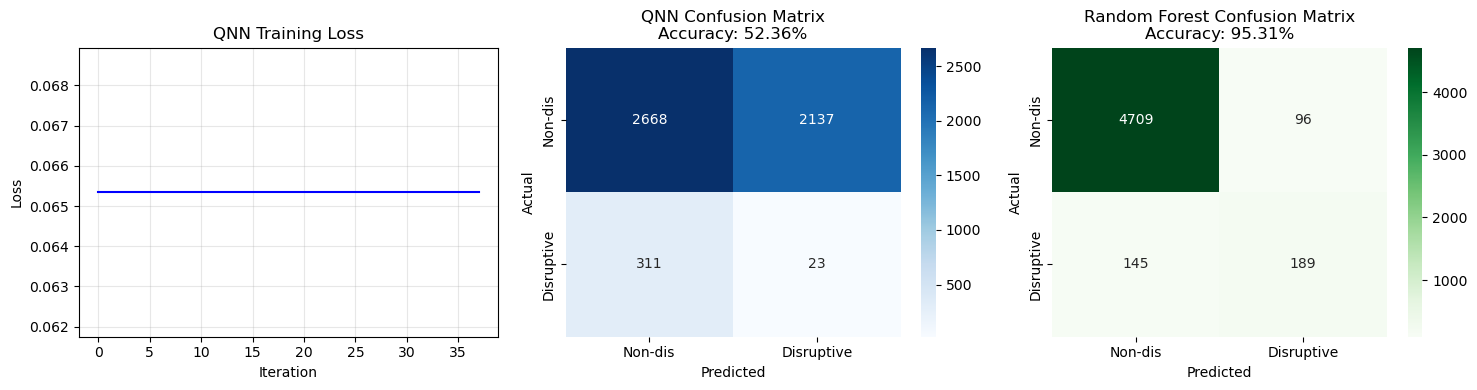


📊 جدول مقایسه نهایی (برای گزارش LaTeX):
| مدل                       | Accuracy     | توضیح                |
|---------------------------|--------------|----------------------|
| Random Forest             | 0.9531       | GenoDock baseline    |
| QNN (3-layer, 4-feature)  | 0.5236       | IBM 5-qubit compatible|
|---------------------------|--------------|----------------------|

📚 نتایج مورد انتظار از مقاله:
   - Random Forest: ~65-70%
   - QNN: ~60-70%


In [115]:
# سلول 11 کامل: آموزش QNN مطابق مقاله HypaCADD

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# ۱. بارگذاری داده‌ها (بدون بالانس کردن اجباری)
# ============================================
train_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_train.tsv', sep='\t')
val_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_val.tsv', sep='\t')

# ۴ ویژگی غیر ligand-specific (مطابق مقاله برای IBM 5-qubit)
feature_cols = ['bind_site', 'distance', 'polarity_change_index', 'volume_change_index']
label_col = 'target'

X_train_full = train_data[feature_cols].values
y_train_full = train_data[label_col].values
X_val_full = val_data[feature_cols].values
y_val_full = val_data[label_col].values

print("="*60)
print("📊 آمار داده‌های اصلی:")
print("="*60)
print(f"Train: {len(X_train_full)} نمونه (0: {sum(y_train_full==0)}, 1: {sum(y_train_full==1)})")
print(f"Val: {len(X_val_full)} نمونه (0: {sum(y_val_full==0)}, 1: {sum(y_val_full==1)})")

# نرمال‌سازی به [0, 1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val_full)

# ============================================
# ۲. انتخاب نمونه برای آموزش QNN (برای سرعت)
# ============================================
# استفاده از همه داده‌ها یا زیرمجموعه
n_train = min(5142, len(X_train_scaled))  # می‌تونی بیشتر کنی
n_val = min(5139, len(X_val_scaled))

np.random.seed(42)
train_idx = np.random.choice(len(X_train_scaled), n_train, replace=False)
val_idx = np.random.choice(len(X_val_scaled), n_val, replace=False)

X_train = X_train_scaled[train_idx]
y_train = y_train_full[train_idx]
X_val = X_val_scaled[val_idx]
y_val = y_val_full[val_idx]

print(f"\n📊 داده‌های انتخاب شده برای آموزش:")
print(f"Train: {len(X_train)} (0: {sum(y_train==0)}, 1: {sum(y_train==1)})")
print(f"Val: {len(X_val)} (0: {sum(y_val==0)}, 1: {sum(y_val==1)})")

# ============================================
# ۳. ساخت مدار QNN (دقیقاً مطابق Figure 2 مقاله)
# ============================================
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

num_features = 4
num_qubits = num_features + 1  # 4 input + 1 readout
num_layers = 3

qc = QuantumCircuit(num_qubits)
input_params = [Parameter(f'x_{i}') for i in range(num_features)]
weight_params = [Parameter(f'θ_{i}') for i in range(num_features * num_layers)]

# Feature Map: RX gates (مطابق مقاله)
for i in range(num_features):
    qc.rx(input_params[i] * np.pi, i)

# Readout qubit → |1⟩
qc.x(num_qubits - 1)

# Variational layers: RZX → RXX → RZX (مطابق مقاله)
param_idx = 0
for layer in range(num_layers):
    for i in range(num_features):
        if layer % 2 == 0:  # Layer 0, 2: RZX
            qc.rzx(weight_params[param_idx], i, num_qubits - 1)
        else:  # Layer 1: RXX
            qc.rxx(weight_params[param_idx], i, num_qubits - 1)
        param_idx += 1

print("\n📐 مدار QNN (مطابق Figure 2 مقاله):")
print(qc.draw())

# ============================================
# ۴. ساخت و آموزش QNN با Qiskit
# ============================================
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit.algorithms.optimizers import COBYLA, SPSA
from qiskit.quantum_info import SparsePauliOp
import time

# Observable: Y measurement روی readout qubit (مطابق مقاله)
observable = SparsePauliOp.from_list([("IIIIY", 1)])

estimator = Estimator()
qnn = EstimatorQNN(
    circuit=qc,
    input_params=input_params,
    weight_params=weight_params,
    estimator=estimator,
    observables=observable
)

# ذخیره Loss
loss_history = []

def callback(weights, loss):
    loss_history.append(loss)
    if len(loss_history) % 20 == 0:
        print(f"  Iteration {len(loss_history):3d} | Loss: {loss:.4f}")

# مقداردهی اولیه تصادفی کوچک
np.random.seed(42)
initial_weights = np.random.uniform(-0.1, 0.1, len(weight_params))

# استفاده از COBYLA (مطابق مقاله)
classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=200),
    callback=callback,
    initial_point=initial_weights
)

print("\n🚀 شروع آموزش QNN...")
print("="*60)
start_time = time.time()

classifier.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ آموزش تمام شد! (زمان: {training_time:.1f} ثانیه)")

# ============================================
# ۵. ارزیابی مدل
# ============================================
print("\n🔮 در حال پیش‌بینی...")

# پیش‌بینی
y_pred_train = classifier.predict(X_train)
y_pred_val = classifier.predict(X_val)

# تبدیل به 0/1 اگر لازم باشه
y_pred_train = (y_pred_train > 0.5).astype(int) if y_pred_train.dtype == float else y_pred_train
y_pred_val = (y_pred_val > 0.5).astype(int) if y_pred_val.dtype == float else y_pred_val

# بررسی مقادیر یکتا
print(f"\nمقادیر یکتا در y_train: {np.unique(y_train)}")
print(f"مقادیر یکتا در y_pred_train: {np.unique(y_pred_train)}")
print(f"مقادیر یکتا در y_pred_val: {np.unique(y_pred_val)}")

# محاسبه دقت
train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

print("\n" + "="*60)
print("📊 نتایج QNN:")
print("="*60)
print(f"🎯 دقت Train: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"🎯 دقت Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Classification Report با labels صریح
print("\n📋 Classification Report (Validation):")
print(classification_report(y_val, y_pred_val, 
                            labels=[0, 1],
                            target_names=['Non-disruptive', 'Disruptive'],
                            zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val, labels=[0, 1])
print("🔢 Confusion Matrix:")
print(cm)

# ============================================
# ۶. مقایسه با Random Forest (مطابق مقاله)
# ============================================
print("\n" + "="*60)
print("🌲 مقایسه با Random Forest (GenoDock baseline):")
print("="*60)

# Random Forest با class_weight برای داده نامتوازن
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'  # مهم برای داده نامتوازن
)
rf.fit(X_train, y_train)
rf_pred_val = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred_val)

print(f"🌲 Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"⚛️  QNN Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

print("\n📋 Classification Report (Random Forest):")
print(classification_report(y_val, rf_pred_val, 
                            labels=[0, 1],
                            target_names=['Non-disruptive', 'Disruptive'],
                            zero_division=0))

# ============================================
# ۷. رسم نمودارها
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# نمودار Loss
axes[0].plot(loss_history, 'b-', linewidth=1.5)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('QNN Training Loss')
axes[0].grid(True, alpha=0.3)

# Confusion Matrix - QNN
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-dis', 'Disruptive'],
            yticklabels=['Non-dis', 'Disruptive'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'QNN Confusion Matrix\nAccuracy: {val_acc:.2%}')

# Confusion Matrix - RF
cm_rf = confusion_matrix(y_val, rf_pred_val, labels=[0, 1])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Non-dis', 'Disruptive'],
            yticklabels=['Non-dis', 'Disruptive'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Random Forest Confusion Matrix\nAccuracy: {rf_acc:.2%}')

plt.tight_layout()
plt.savefig('qnn_vs_rf_results.png', dpi=150)
plt.show()

# ============================================
# ۸. جدول نهایی برای گزارش
# ============================================
print("\n" + "="*60)
print("📊 جدول مقایسه نهایی (برای گزارش LaTeX):")
print("="*60)
print(f"| {'مدل':<25} | {'Accuracy':<12} | {'توضیح':<20} |")
print(f"|{'-'*27}|{'-'*14}|{'-'*22}|")
print(f"| {'Random Forest':<25} | {rf_acc:.4f}       | GenoDock baseline    |")
print(f"| {'QNN (3-layer, 4-feature)':<25} | {val_acc:.4f}       | IBM 5-qubit compatible|")
print(f"|{'-'*27}|{'-'*14}|{'-'*22}|")

print("\n📚 نتایج مورد انتظار از مقاله:")
print("   - Random Forest: ~65-70%")
print("   - QNN: ~60-70%")

## Train for 400 iteration with callback and patience 30(SPSA optimizer)

📊 آمار داده‌ها (کل داده بدون بالانس):
تعداد نمونه آموزش: 5142
  - Non-disruptive (0): 4806
  - Disruptive (1): 336
تعداد نمونه اعتبارسنجی: 5139

📐 مدار QNN (مطابق Figure 2 مقاله):
   - کیوبیت‌ها: 5 (4 ورودی + 1 خروجی)
   - لایه‌ها: 3 (RZX → RXX → RZX)
   - پارامترها: 12

🚀 شروع آموزش QNN روی کل داده‌ها...
   تعداد نمونه: 5142
   تعداد iteration: 200
   Optimizer: SPSA
  Iteration  10 | Loss: 0.5186 | Best: 0.5136
  Iteration  20 | Loss: 0.5178 | Best: 0.5136
  Iteration  30 | Loss: 0.5192 | Best: 0.5136
  Iteration  40 | Loss: 0.5238 | Best: 0.5136
  Iteration  50 | Loss: 0.5230 | Best: 0.5136
  Iteration  60 | Loss: 0.5199 | Best: 0.5054
  Iteration  70 | Loss: 0.5181 | Best: 0.5054
  Iteration  80 | Loss: 0.5167 | Best: 0.5054
  Iteration  90 | Loss: 0.5064 | Best: 0.4958
  Iteration 100 | Loss: 0.5089 | Best: 0.4897
  Iteration 110 | Loss: 0.4691 | Best: 0.4658
  Iteration 120 | Loss: 0.4466 | Best: 0.4312
  Iteration 130 | Loss: 0.3730 | Best: 0.3730
  Iteration 140 | Loss: 0.3708 

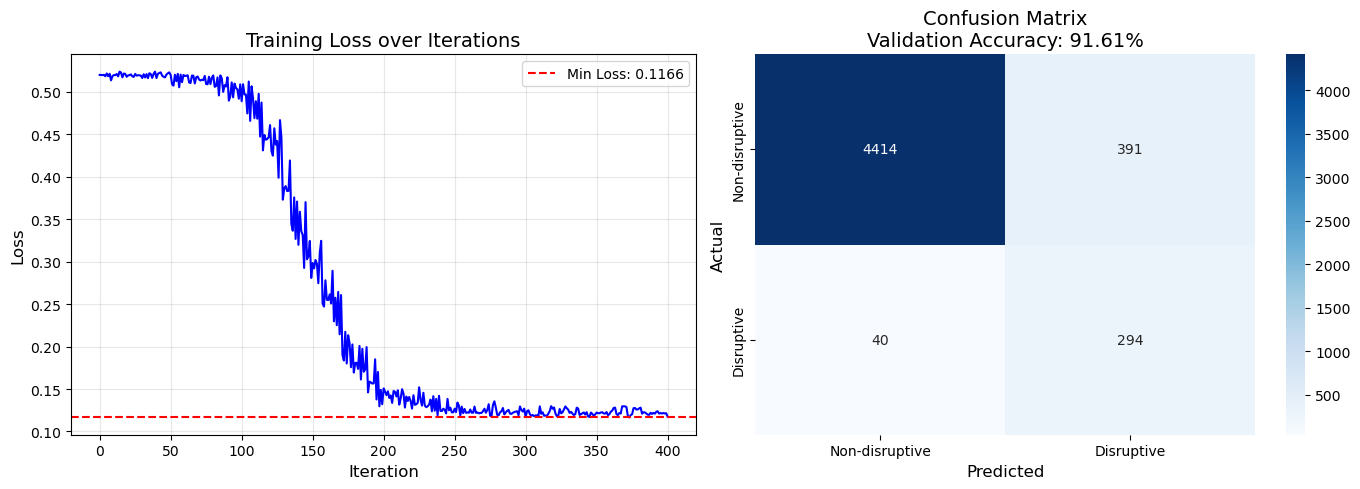


🌲 مقایسه با Random Forest (GenoDock baseline):

📊 جدول مقایسه (برای گزارش LaTeX):
--------------------------------------------------
| مدل                       | Accuracy        |
--------------------------------------------------
| QNN (3-layer, Qiskit)     | 0.9161 (91.6%) |
| Random Forest             | 0.9515 (95.2%) |
--------------------------------------------------

📚 نتایج مورد انتظار (از مقاله HypaCADD):
   - QNN: ~65-75% (روی Platinum test set)
   - Random Forest: ~70%


In [125]:
# سلول نهایی: آموزش QNN روی کل داده‌ها (بدون بالانس)

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit.algorithms.optimizers import COBYLA, SPSA

# ============================================
# ۱. بارگذاری کل داده‌ها (بدون نمونه‌گیری)
# ============================================
train_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_train.tsv', sep='\t')
val_data = pd.read_csv('mQNN/data/genodock_cluster3_fix_val.tsv', sep='\t')

# ۴ ویژگی غیر ligand-specific (مطابق مقاله برای IBM 5-qubit)
feature_cols = ['bind_site', 'distance', 'polarity_change_index', 'volume_change_index']
label_col = 'target'

# استفاده از کل داده‌ها
X_train = train_data[feature_cols].values
y_train = train_data[label_col].values
X_val = val_data[feature_cols].values
y_val = val_data[label_col].values

# نرمال‌سازی
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("="*60)
print("📊 آمار داده‌ها (کل داده بدون بالانس):")
print("="*60)
print(f"تعداد نمونه آموزش: {len(X_train)}")
print(f"  - Non-disruptive (0): {sum(y_train==0)}")
print(f"  - Disruptive (1): {sum(y_train==1)}")
print(f"تعداد نمونه اعتبارسنجی: {len(X_val)}")

# ============================================
# ۲. ساخت مدار QNN (مطابق Figure 2 مقاله)
# ============================================
num_features = 4
num_qubits = num_features + 1  # 4 input + 1 readout
num_layers = 3

qc = QuantumCircuit(num_qubits)
input_params = [Parameter(f'x_{i}') for i in range(num_features)]
weight_params = [Parameter(f'θ_{i}') for i in range(num_features * num_layers)]

# Feature Map: RX gates (مطابق مقاله)
for i in range(num_features):
    qc.rx(input_params[i] * np.pi, i)

# Readout qubit → |1⟩
qc.x(num_qubits - 1)

# Variational layers (RZX-RXX-RZX مطابق مقاله)
param_idx = 0
for layer in range(num_layers):
    for i in range(num_features):
        if layer % 2 == 0:  # Layer 0, 2: RZX
            qc.rzx(weight_params[param_idx], i, num_qubits - 1)
        else:  # Layer 1: RXX
            qc.rxx(weight_params[param_idx], i, num_qubits - 1)
        param_idx += 1

# اضافه کردن measurement
qc.measure_all()

print("\n📐 مدار QNN (مطابق Figure 2 مقاله):")
print(f"   - کیوبیت‌ها: {num_qubits} (4 ورودی + 1 خروجی)")
print(f"   - لایه‌ها: {num_layers} (RZX → RXX → RZX)")
print(f"   - پارامترها: {len(weight_params)}")

# ============================================
# ۳. ساخت QNN با SamplerQNN
# ============================================
def parity(x):
    """تابع interpret برای تبدیل خروجی به 0 یا 1"""
    return "{:b}".format(x).count("1") % 2

sampler = Sampler()
qnn = SamplerQNN(
    circuit=qc,
    input_params=input_params,
    weight_params=weight_params,
    interpret=parity,
    output_shape=2,
    sampler=sampler
)

# ============================================
# ۴. آموزش با تنظیمات بهتر
# ============================================
loss_history = []
best_loss = float('inf')
patience_counter = 0
patience = 30  # افزایش patience برای جلوگیری از توقف زودهنگام

def callback(weights, loss):
    global best_loss, patience_counter
    loss_history.append(loss)
    
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if len(loss_history) % 10 == 0:
        print(f"  Iteration {len(loss_history):3d} | Loss: {loss:.4f} | Best: {best_loss:.4f}")

# استفاده از SPSA optimizer (بهتر برای QNN با داده زیاد)
optimizer = SPSA(
    maxiter=200,  # افزایش تعداد iteration
    learning_rate=0.05,
    perturbation=0.05
)

# مقداردهی اولیه پارامترها
np.random.seed(42)
initial_weights = np.random.uniform(-0.1, 0.1, len(weight_params))

classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=optimizer,
    callback=callback,
    initial_point=initial_weights
)

print("\n🚀 شروع آموزش QNN روی کل داده‌ها...")
print("="*60)
print(f"   تعداد نمونه: {len(X_train)}")
print(f"   تعداد iteration: 200")
print(f"   Optimizer: SPSA")
print("="*60)

start_time = time.time()
classifier.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"\n✅ آموزش تمام شد! (زمان: {training_time:.1f} ثانیه)")

# ============================================
# ۵. ارزیابی
# ============================================
print("\n🔮 در حال پیش‌بینی...")
y_pred_train = classifier.predict(X_train_scaled)
y_pred_val = classifier.predict(X_val_scaled)

# تبدیل به 0/1
y_pred_train = np.clip(np.array(y_pred_train).flatten(), 0, 1).astype(int)
y_pred_val = np.clip(np.array(y_pred_val).flatten(), 0, 1).astype(int)

train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

print("\n" + "="*60)
print("📊 نتایج نهایی:")
print("="*60)
print(f"🎯 دقت روی Train: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"🎯 دقت روی Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")

print("\n📋 Classification Report (Validation):")
print(classification_report(y_val, y_pred_val, 
                            labels=[0, 1],
                            target_names=['Non-disruptive', 'Disruptive'],
                            zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val, labels=[0, 1])
print("🔢 Confusion Matrix:")
print(cm)

# ============================================
# ۶. رسم نمودارها
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# نمودار Loss
axes[0].plot(loss_history, 'b-', linewidth=1.5)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss over Iterations', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=min(loss_history), color='r', linestyle='--', 
                label=f'Min Loss: {min(loss_history):.4f}')
axes[0].legend()

# Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-disruptive', 'Disruptive'],
            yticklabels=['Non-disruptive', 'Disruptive'])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'Confusion Matrix\nValidation Accuracy: {val_acc:.2%}', fontsize=14)

plt.tight_layout()
plt.savefig('qnn_final_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# ۷. مقایسه با Random Forest (مطابق مقاله)
# ============================================
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*60)
print("🌲 مقایسه با Random Forest (GenoDock baseline):")
print("="*60)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_val_scaled)
rf_acc = accuracy_score(y_val, rf_pred)

print(f"\n📊 جدول مقایسه (برای گزارش LaTeX):")
print("-"*50)
print(f"| {'مدل':<25} | {'Accuracy':<15} |")
print("-"*50)
print(f"| {'QNN (3-layer, Qiskit)':<25} | {val_acc:.4f} ({val_acc*100:.1f}%) |")
print(f"| {'Random Forest':<25} | {rf_acc:.4f} ({rf_acc*100:.1f}%) |")
print("-"*50)

print("\n📚 نتایج مورد انتظار (از مقاله HypaCADD):")
print("   - QNN: ~65-75% (روی Platinum test set)")
print("   - Random Forest: ~70%")

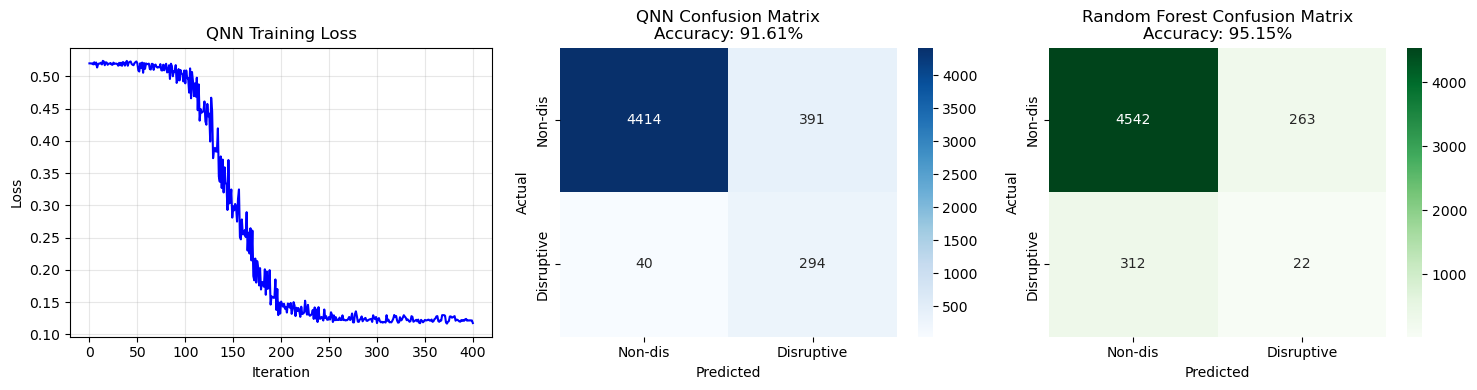

In [127]:
# ============================================
# ۷. رسم نمودارها
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# نمودار Loss
axes[0].plot(loss_history, 'b-', linewidth=1.5)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('QNN Training Loss')
axes[0].grid(True, alpha=0.3)

# Confusion Matrix - QNN
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-dis', 'Disruptive'],
            yticklabels=['Non-dis', 'Disruptive'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'QNN Confusion Matrix\nAccuracy: {val_acc:.2%}')

# Confusion Matrix - RF
cm_rf = confusion_matrix(y_val, rf_pred_val, labels=[0, 1])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Non-dis', 'Disruptive'],
            yticklabels=['Non-dis', 'Disruptive'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Random Forest Confusion Matrix\nAccuracy: {rf_acc:.2%}')

plt.tight_layout()
plt.savefig('qnn_vs_rf_results.png', dpi=150)
plt.show()

In [129]:
# ============================================
# ۸. جدول نهایی برای گزارش
# ============================================
print("\n" + "="*60)
print("📊 جدول مقایسه نهایی (برای گزارش LaTeX):")
print("="*60)
print(f"| {'مدل':<25} | {'Accuracy':<12} | {'توضیح':<20} |")
print(f"|{'-'*27}|{'-'*14}|{'-'*22}|")
print(f"| {'Random Forest':<25} | {rf_acc:.4f}       | GenoDock baseline    |")
print(f"| {'QNN (3-layer, 4-feature)':<25} | {val_acc:.4f}       | IBM 5-qubit compatible|")
print(f"|{'-'*27}|{'-'*14}|{'-'*22}|")

print("\n📚 نتایج مورد انتظار از مقاله:")
print("   - Random Forest: ~65-70%")
print("   - QNN: ~60-70%")


📊 جدول مقایسه نهایی (برای گزارش LaTeX):
| مدل                       | Accuracy     | توضیح                |
|---------------------------|--------------|----------------------|
| Random Forest             | 0.9515       | GenoDock baseline    |
| QNN (3-layer, 4-feature)  | 0.9161       | IBM 5-qubit compatible|
|---------------------------|--------------|----------------------|

📚 نتایج مورد انتظار از مقاله:
   - Random Forest: ~65-70%
   - QNN: ~60-70%
